In [ ]:
import numpy as np
import pandas as pd
import utils
eta=1
rd = 147.09
rd_err = 0.26
c_light = 299792.458
z_bao, bao_val, bao_err = np.loadtxt('data/bao_data.dat', unpack=True)
_, h_val, h_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_cp, _, _ = np.loadtxt('output/mB_cp_summary.txt', unpack=True)
bao_cov = np.loadtxt('output/bao_cov.txt')

mB_match = np.load("output/mB_baomatch_CPI.npy")
mB_match_cov_CPI = np.load("output/mB_baomatch_cov_CPI.npy")
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values

mB_cp_chain = np.load("output/mB_cp_chain.npy")

z_plot = np.linspace(0.01, max(z_sn) * 1.1, 1000)

z_match = z_bao
# is_dv = [True, True, True, False, False, False, False, False, False, False, False]
# D_L = np.zeros(len(z_match))
# for i in range(len(z_match)):
#     if is_dv[i]:
#         dm_eff = np.sqrt((bao_val[i]**3 * rd**3 * h_val[i]) / (z_match[i] * c_light))
#         D_L[i] = (dm_eff * (1 + z_match[i]))
#     else:
#         D_L[i] = (bao_val[i] * rd * (1 + z_match[i]))

n_MC = 1000
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
DL_bao_DV, DL_bao_DV_err = utils.bao_DV_to_DL(z_bao_dv, DV_rd, DV_rd_err, H_dv, H_dv_err, rd, rd_err)
DL_bao_DM, DL_bao_DM_err = utils.bao_DM_to_DL(z_bao_dm, DM_rd, DM_rd_err, rd, rd_err)
# 合并 BAO 点（保存原始观测数据）
DL_bao_obs = np.concatenate((DL_bao_DV, DL_bao_DM))        # BAO观测距离
DL_bao_obs_err = np.concatenate((DL_bao_DV_err, DL_bao_DM_err)) # BAO观测误差
# GP拟合BAO数据
gp_bao = utils.fit_gp_DL(z_match, DL_bao_obs, DL_bao_obs_err)
DL_bao_gp_mean, DL_bao_gp_std = gp_bao.predict(z_plot.reshape(-1,1), return_std=True)
# 从GP中抽取BAO距离样本
DL_bao_samples = gp_bao.sample_y(z_plot.reshape(-1,1), n_MC).T # 从高斯过程中每个z_plot处抽取n_MC个样本

# MB = mB_match-5*np.log10(D_L)-25
# print(MB)


mB_samples = np.load('output/mB_rec_samples')

MB_samples = mB_samples - 5*np.log10(DL_bao_samples)-25

MB_mean = np.mean(MB_samples, axis=0)   # (N_z,)
MB_std  = np.std(MB_samples, axis=0)    # (N_z,)

FileNotFoundError: [Errno 2] No such file or directory: 'output/mB_match_CPI.npy'

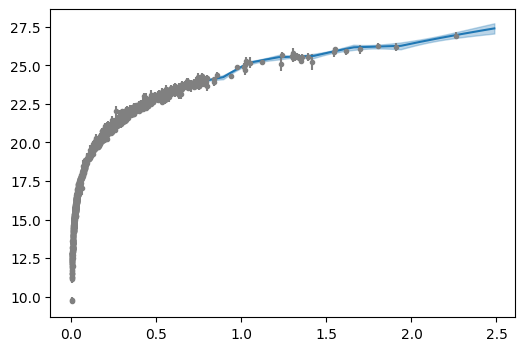

In [ ]:
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
mB_obs_std = np.sqrt(np.diag(cov_full))

import matplotlib.pyplot as plt
mB_mean = np.mean(mB_samples, axis=0)   # (N_z,)
mB_std  = np.std(mB_samples, axis=0)    # (N_z,)
mask = z_plot > 0.1
plt.figure(figsize=(6, 4))
plt.errorbar(z_sn, mB_obs, yerr=mB_obs_std, fmt='.', color='gray', label='Pantheon+ Data')
plt.plot(z_plot, mB_mean, color="C0", label=r"$m_B(z)$ mean")
plt.fill_between(
    z_plot[mask],
    (mB_mean - mB_std)[mask],
    (mB_mean + mB_std)[mask],
    color="C0",
    alpha=0.3,
    label=r"$1\sigma$"
)


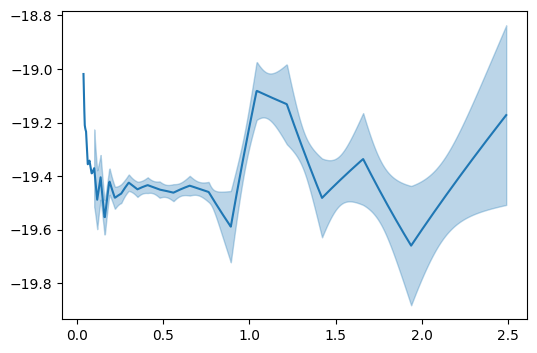

In [ ]:
import matplotlib.pyplot as plt
mask = z_plot > 0.1
plt.figure(figsize=(6, 4))
plt.plot(z_plot, MB_mean, color="C0", label=r"$M_B(z)$ mean")
plt.fill_between(
    z_plot[mask],
    (MB_mean - MB_std)[mask],
    (MB_mean + MB_std)[mask],
    color="C0",
    alpha=0.3,
    label=r"$1\sigma$"
)
